Dataset Preview:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude   MEDV  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Summary Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154  

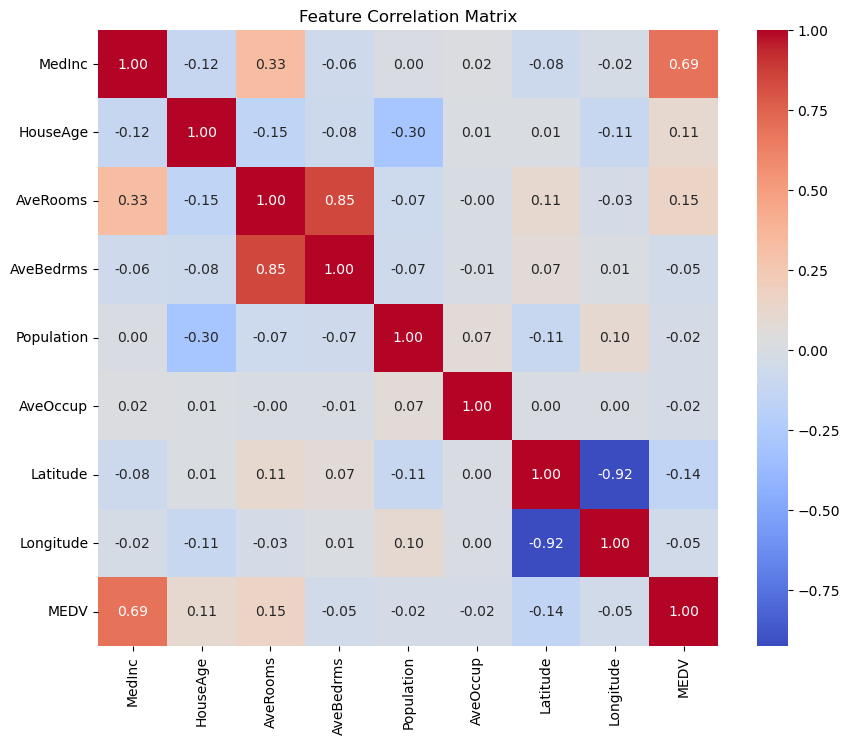


Training Set Shape: (16512, 8), Testing Set Shape: (4128, 8)

Model Coefficients:
Intercept: -37.02327770606405
Feature Coefficients: {'MedInc': 0.4486749096657176, 'HouseAge': 0.009724257517905023, 'AveRooms': -0.12332334282795863, 'AveBedrms': 0.7831449067929727, 'Population': -2.0296205801885327e-06, 'AveOccup': -0.00352631848713407, 'Latitude': -0.41979248658835966, 'Longitude': -0.43370806496398745}

Actual vs Predicted House Prices (First 5 rows):
        Actual  Predicted
20046  0.47700   0.719123
3024   0.45800   1.764017
15663  5.00001   2.709659
20484  2.18600   2.838926
9814   2.78000   2.604657

Model Performance Metrics:
Mean Squared Error (MSE): 0.56
Root Mean Squared Error (RMSE): 0.75
R-squared (R²): 0.58


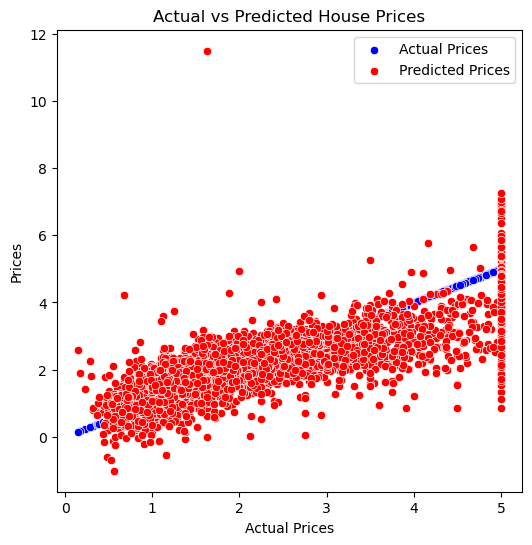

In [8]:
# Step 1: Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load the California Housing Dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MEDV'] = data.target  # Target variable (house price)

# Display the first few rows of the dataset
print("Dataset Preview:")
print(df.head())

# Step 3: Exploratory Data Analysis (EDA)
# Summary statistics
print("\nDataset Summary Statistics:")
print(df.describe())

# Correlation matrix visualization
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Step 4: Splitting Data into Training and Testing Sets
X = df.drop(columns=['MEDV'])  # Independent variables (features)
y = df['MEDV']  # Dependent variable (target)

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining Set Shape: {X_train.shape}, Testing Set Shape: {X_test.shape}")

# Step 5: Train the Multiple Linear Regression Model
model = LinearRegression()  # Initialize the model
model.fit(X_train, y_train) # Train the model on the training data

# Display model coefficients
print("\nModel Coefficients:")
print(f"Intercept: {model.intercept_}")
print(f"Feature Coefficients: {dict(zip(data.feature_names, model.coef_))}")

# Step 6: Make Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nActual vs Predicted House Prices (First 5 rows):")
print(results.head())

# Step 7: Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Step 8: Visualizing Predictions

plt.figure(figsize=(6, 6))

# Scatter plot for actual prices (blue)
sns.scatterplot(x=y_test, y=y_test, color='blue', label='Actual Prices')

# Scatter plot for predicted prices (red)
sns.scatterplot(x=y_test, y=y_pred, color='red', label='Predicted Prices')

# Labels and title
plt.xlabel("Actual Prices")
plt.ylabel("Prices")
plt.title("Actual vs Predicted House Prices")

# Show legend
plt.legend()

# Show the plot
plt.show()